# Clinical and Environmental Risk Profiling in Youth with Familial Psychiatric Risk (ABCD cohort)

> This notebook examines the non-imaging variables in the ABCD cohort: demographics, psychopathology (CBCL), socioeconomic indicators, prenatal history, and peer/stress factors. We explore distributions, group differences (PH+ vs PH−), and subtype contrasts.

**Data:** Real ABCD analyses used N=2,387 participants with ComBat-harmonized features across 22 sites. Some demoed features use synthetic ROI features generated by `brainrisk.data.synthetic` (N=200, 400 features, 3 sites).

**Note:** The visualizations use aggregate, group-level summaries from ABCD data. All summaries have been previously disseminated in the author’s MSc thesis and do not permit identification of individual participants. This repository does not contain any ABCD Study data, subject-level results, or identifiable participant information. Some visualizations use synthetic data for reproducibility. Patterns in real data are discussed in inline annotations where they differ.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib_inline.backend_inline import set_matplotlib_formats

from brainrisk.data.synthetic import generate_clinical_data, generate_labels

# Figure resolution: adjust the DPI below to increase or decrease image quality.
# Currently set to 60 to keep the repository lightweight and fast to load.
set_matplotlib_formats('png')
mpl.rcParams["figure.dpi"] = 60
mpl.rcParams["savefig.dpi"] = 60

sns.set_theme(style="whitegrid", font_scale=1.05)
SUBTYPE_COLORS = {"PH−": "#636363", "S1": "#e66101", "S2": "#5e3c99", "S3": "#1b9e77"}

### 1. Load & Inspect Data

In [2]:
OUT = Path("../artifacts/notebook_scratch")
N, SEED = 200, 42

labels_df = generate_labels(n_subjects=N, seed=SEED, output_dir=OUT)
clinical_df = generate_clinical_data(n_subjects=N, n_sites=3, seed=SEED, output_dir=OUT, labels=labels_df)

print(f"N = {len(clinical_df)}")
print(f"\nColumns: {list(clinical_df.columns)}")
clinical_df.describe().round(2)

N = 200

Columns: ['subject_id', 'site', 'age_years', 'sex', 'risk_group', 'hydra_subtype', 'cbcl_internalizing', 'cbcl_externalizing', 'family_income_k', 'maternal_substance_use', 'peer_support']


,age_years,hydra_subtype,cbcl_internalizing,cbcl_externalizing,family_income_k,maternal_substance_use,peer_support
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,10.00,2.02,56.03,52.38,86.18,0.29,2.88
std,0.59,0.81,5.66,5.41,22.56,0.45,0.56
min,9.01,1.00,40.64,37.39,27.67,0.00,1.53
25%,9.47,1.00,52.42,48.54,69.39,0.00,2.48
50%,9.96,2.00,56.18,52.46,85.53,0.00,2.89
75%,10.58,3.00,59.62,55.96,98.69,1.00,3.19
max,10.99,3.00,69.33,68.59,153.96,1.00,4.48


### 2. Quick demographic Overview

In the ABCD Study, the sample comprised children aged 9–10. Key demographic breakdowns:

In [3]:
def count_table(series, label):
    tbl = (
        series.value_counts(dropna=False)
        .rename_axis(label)
        .reset_index(name="count")
    )
    tbl["percent"] = (tbl["count"] / tbl["count"].sum() * 100).round(1)
    return tbl

# Sex
sex_table = count_table(clinical_df["sex"], "sex")

# Risk group
risk_group_table = count_table(clinical_df["risk_group"], "risk_group")

# Subtype
subtype_table = (
    clinical_df["hydra_subtype"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("hydra_subtype")
    .reset_index(name="count")
)
subtype_table["subtype_label"] = subtype_table["hydra_subtype"].apply(lambda x: f"S{x}")
subtype_table["percent"] = (subtype_table["count"] / subtype_table["count"].sum() * 100).round(1)
subtype_table = subtype_table[["subtype_label", "count", "percent"]]

print("  Sex Distribution")
print(sex_table)

print("\n  Familial Risk Group")
print(risk_group_table)

print("\n  HYDRA Subtype (PH+ only)")
print(subtype_table)


  Sex Distribution
  sex  count  percent
0   F    106     53.0
1   M     94     47.0

  Familial Risk Group
  risk_group  count  percent
0        PH+    116     58.0
1        PH-     84     42.0

  HYDRA Subtype (PH+ only)
  subtype_label  count  percent
0            S1     63     31.5
1            S2     69     34.5
2            S3     68     34.0


### 3. Psychopathology: CBCL Scores at Baseline

The Child Behavior Checklist (CBCL) provides T-scores for internalizing and externalizing problems. Clinical range is T ≥ 64; borderline is T = 60–63. Even within our "asymptomatic" sample (no DSM diagnoses), PH+ youth showed elevated subclinical symptoms.

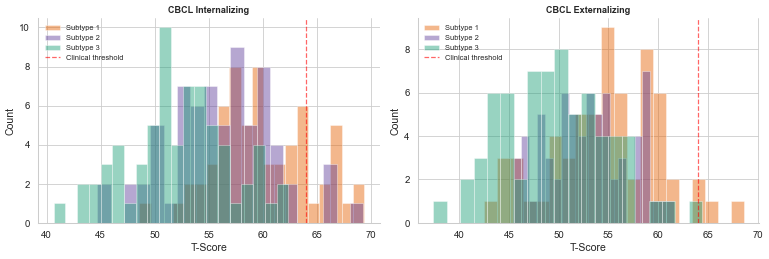

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for i, (measure, title) in enumerate([
    ("cbcl_internalizing", "CBCL Internalizing"),
    ("cbcl_externalizing", "CBCL Externalizing"),
]):
    ax = axes[i]
    for st in sorted(clinical_df["hydra_subtype"].unique()):
        data = clinical_df.loc[clinical_df["hydra_subtype"] == st, measure]
        ax.hist(data, bins=20, alpha=0.45, label=f"Subtype {st}",
                color=list(SUBTYPE_COLORS.values())[st])
    ax.axvline(64, ls="--", color="red", alpha=0.6, label="Clinical threshold")
    ax.set_xlabel("T-Score")
    ax.set_ylabel("Count")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### 4. Real-Data Socioeconomic & Environmental Contrasts (ABCD results)

HYDRA subtypes were linked to distinct environmental profiles in the real data. Subtype 2 showed the most socioeconomic disadvantage; Subtype 3 had the strongest peer support.

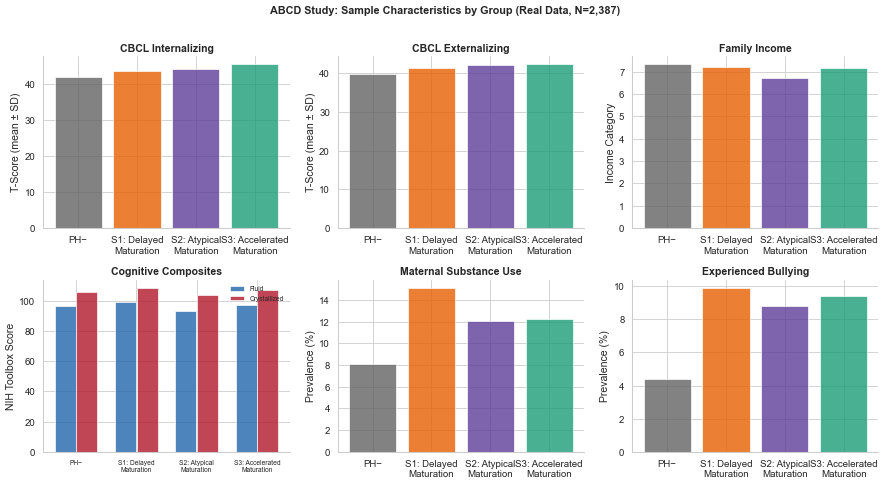


Sample sizes: PH− = 1446, S1 = 324, S2 = 339, S3 = 278


In [5]:
# Load aggregate real-data statistics from assets/data/
chars_path = Path("../assets/data/sample_characteristics.json")
if chars_path.exists():
    chars = json.loads(chars_path.read_text())

    groups = ["PH_minus", "subtype_1", "subtype_2", "subtype_3"]
    labels = ["PH−", "S1: Delayed\nMaturation", "S2: Atypical\nMaturation", "S3: Accelerated\nMaturation"]
    n = [chars["sample_sizes"][g] for g in groups]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # CBCL Internalizing
    ax = axes[0, 0]
    means = [chars["psychopathology_baseline"][g]["cbcl_int_mean"] for g in groups]
    sds = [chars["psychopathology_baseline"][g]["cbcl_int_sd"] for g in groups]
    colors = [SUBTYPE_COLORS.get(k, "#999") for k in ["PH−", "S1", "S2", "S3"]]
    ax.bar(labels, means, color=colors, alpha=0.8, edgecolor="white")
    ax.set_ylabel("T-Score (mean ± SD)")
    ax.set_title("CBCL Internalizing", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    # CBCL Externalizing
    ax = axes[0, 1]
    means = [chars["psychopathology_baseline"][g]["cbcl_ext_mean"] for g in groups]
    sds = [chars["psychopathology_baseline"][g]["cbcl_ext_sd"] for g in groups]
    ax.bar(labels, means, color=colors, alpha=0.8, edgecolor="white")
    ax.set_ylabel("T-Score (mean ± SD)")
    ax.set_title("CBCL Externalizing", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    # Family Income
    ax = axes[0, 2]
    means = [chars["socioeconomic"][g]["income_mean"] for g in groups]
    sds = [chars["socioeconomic"][g]["income_sd"] for g in groups]
    ax.bar(labels, means, color=colors, alpha=0.8, edgecolor="white")
    ax.set_ylabel("Income Category")
    ax.set_title("Family Income", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    # Cognition
    ax = axes[1, 0]
    fluid = [chars["cognition"][g]["fluid_mean"] for g in groups]
    cryst = [chars["cognition"][g]["crystallized_mean"] for g in groups]
    x = np.arange(len(labels))
    ax.bar(x - 0.18, fluid, 0.35, label="Fluid", color="#2166ac", alpha=0.8)
    ax.bar(x + 0.18, cryst, 0.35, label="Crystallized", color="#b2182b", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("NIH Toolbox Score")
    ax.set_title("Cognitive Composites", fontweight="bold")
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # Maternal substance use
    ax = axes[1, 1]
    pcts = [chars["prenatal"][g]["maternal_substance_use_pct"] for g in groups]
    ax.bar(labels, pcts, color=colors, alpha=0.8, edgecolor="white")
    ax.set_ylabel("Prevalence (%)")
    ax.set_title("Maternal Substance Use", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    # Bullying
    ax = axes[1, 2]
    pcts = [chars["peer_and_stress"][g]["bullying_pct"] for g in groups]
    ax.bar(labels, pcts, color=colors, alpha=0.8, edgecolor="white")
    ax.set_ylabel("Prevalence (%)")
    ax.set_title("Experienced Bullying", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("ABCD Study: Sample Characteristics by Group (Real Data, N=2,387)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    print(f"\nSample sizes: PH− = {n[0]}, S1 = {n[1]}, S2 = {n[2]}, S3 = {n[3]}")
else:
    print("⚠ assets/data/sample_characteristics.json not found — skipping real-data visualization.")

---
**Summary:** PH+ youth carry elevated subclinical symptoms, greater socioeconomic adversity, and more prenatal/perinatal risk factors than PH− peers. Within PH+, HYDRA subtypes map onto distinct environmental profiles: Subtype 2 shows the greatest disadvantage, while Subtype 3 benefits from stronger protective factors. These non-imaging contrasts complement the neuroimaging signatures explored in `03_hydra_analysis.ipynb`.